# TCN + BiGRU + XGBoost -- CMAPSS Failure Prediction

**Pipeline:**
1. Sliding window sequence construction
2. TCN -- dilated causal convolutions for local/global temporal features
3. BiGRU -- forward + backward temporal dependencies
4. Attention pooling -- sequence summary vector
5. XGBoost GridSearchCV -- optimal hyperparameters on deep features
6. Final XGBoost classifier -- failure prediction

All four CMAPSS datasets (FD001-FD004) are supported; select via `CFG['dataset']`.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
import numpy as np
import pandas as pd
import os, warnings, random
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, fbeta_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    precision_recall_curve, average_precision_score, roc_curve,
    make_scorer,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold

import xgboost as xgb
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: cuda


## Configuration

In [7]:
BASE = '/content/drive/MyDrive/data'

CFG = {
    # --- Data ---
    'dataset'          : 'FD001',   # FD001 | FD002 | FD003 | FD004
    'rul_threshold'    : 30,
    'seq_len'          : 40,        # sliding window length
    'stride'           : 1,
    'val_engine_frac'  : 0.15,

    # --- TCN ---
    'tcn_channels'     : [64, 128, 128, 64],
    'tcn_kernel'       : 3,
    'tcn_dropout'      : 0.2,

    # --- BiGRU ---
    'gru_hidden'       : 128,
    'gru_layers'       : 2,
    'gru_dropout'      : 0.3,

    # --- Embedding ---
    'embed_dim'        : 128,

    # --- Training ---
    'epochs'           : 60,
    'batch_size'       : 256,
    'lr'               : 1e-3,
    'weight_decay'     : 1e-4,
    'patience'         : 12,
    'focal_gamma'      : 2.5,   # higher gamma -> harder focus on false negatives

    # --- Recall-boost knobs ---
    'pos_weight_boost' : 2.0,   # multiply neg/pos ratio by this in focal loss + XGBoost
    'recall_beta'      : 2.0,   # F-beta: beta>1 weights recall over precision
    'min_precision'    : 0.35,  # threshold search: skip thresholds below this precision

    # --- XGBoost base defaults (overridden by GridSearchCV) ---
    'xgb_rounds'       : 800,
    'xgb_lr'           : 0.03,
    'xgb_depth'        : 6,
    'xgb_subsample'    : 0.8,
    'xgb_colsample'    : 0.8,
    'xgb_min_child'    : 3,   # lower -> can split on small positive groups
    'xgb_alpha'        : 0.1,
    'xgb_lambda'       : 1.0,
    'xgb_es_rounds'    : 40,

    # --- GridSearchCV ---
    'grid_cv_folds'    : 3,
    'grid_n_jobs'      : -1,
}

## Data Loading and Preprocessing

In [8]:
COLUMNS = (
    ['unit_number', 'time_in_cycles']
    + [f'op_{i}' for i in range(1, 4)]
    + [f's{i}'  for i in range(1, 22)]
)

# Sensors with near-zero variance (uninformative)
DROP_SENSORS = ['s1', 's5', 's6', 's10', 's16', 's18', 's19']


def load_raw(fd):
    train = pd.read_csv(f'{BASE}/train_{fd}.txt', sep=r'\s+', header=None, names=COLUMNS)
    test  = pd.read_csv(f'{BASE}/test_{fd}.txt',  sep=r'\s+', header=None, names=COLUMNS)
    rul   = pd.read_csv(f'{BASE}/RUL_{fd}.txt',   header=None, names=['RUL'])
    return train, test, rul


def add_rul(df):
    max_c = df.groupby('unit_number')['time_in_cycles'].max()
    df = df.join(max_c.rename('max_c'), on='unit_number')
    df['RUL'] = df['max_c'] - df['time_in_cycles']
    return df.drop('max_c', axis=1)


def get_features(df):
    drop = ['unit_number', 'time_in_cycles', 'RUL'] + DROP_SENSORS
    return [c for c in df.columns if c not in drop]


def split_train_val(train_df, val_frac, seed=42):
    units = train_df['unit_number'].unique()
    rng   = np.random.RandomState(seed)
    val_units = rng.choice(units, size=int(len(units) * val_frac), replace=False)
    val_mask  = train_df['unit_number'].isin(val_units)
    return train_df[~val_mask].copy(), train_df[val_mask].copy()


def make_sliding_windows(df, feat_cols, seq_len, stride, threshold):
    """Build sliding-window sequences; label=1 if RUL < threshold at last step."""
    X_list, y_list = [], []
    for uid, group in df.groupby('unit_number'):
        arr    = group[feat_cols].values.astype(np.float32)
        labels = (group['RUL'].values < threshold).astype(np.int64)
        T = len(arr)
        for start in range(0, T - seq_len + 1, stride):
            end = start + seq_len
            X_list.append(arr[start:end])
            y_list.append(labels[end - 1])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)


def make_test_windows(test_df, rul_df, feat_cols, seq_len, threshold):
    """For each test engine take the last seq_len timesteps; label from true RUL."""
    X_list, y_list = [], []
    for idx, (uid, group) in enumerate(test_df.groupby('unit_number')):
        arr = group[feat_cols].values.astype(np.float32)
        if len(arr) >= seq_len:
            window = arr[-seq_len:]
        else:
            pad    = np.zeros((seq_len - len(arr), arr.shape[1]), dtype=np.float32)
            window = np.vstack([pad, arr])
        true_rul = rul_df.iloc[idx]['RUL']
        X_list.append(window)
        y_list.append(int(true_rul < threshold))
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.int64)


# Load
FD = CFG['dataset']
train_raw, test_raw, rul_raw = load_raw(FD)
train_raw = add_rul(train_raw)

# Engine-level split (no leakage)
tr_df, val_df = split_train_val(train_raw, CFG['val_engine_frac'])
feat_cols = get_features(tr_df)
print(f'Features ({len(feat_cols)}): {feat_cols}')

# Standardise (fit on train only)
scaler = StandardScaler()
tr_df[feat_cols]    = scaler.fit_transform(tr_df[feat_cols])
val_df[feat_cols]   = scaler.transform(val_df[feat_cols])
test_raw[feat_cols] = scaler.transform(test_raw[feat_cols])

# Build windows
SL, ST, TH = CFG['seq_len'], CFG['stride'], CFG['rul_threshold']
X_tr,  y_tr  = make_sliding_windows(tr_df,  feat_cols, SL, ST, TH)
X_val, y_val = make_sliding_windows(val_df, feat_cols, SL, ST, TH)
X_te,  y_te  = make_test_windows(test_raw, rul_raw, feat_cols, SL, TH)

print(f'Train : {X_tr.shape}  | pos ratio: {y_tr.mean():.3f}')
print(f'Val   : {X_val.shape} | pos ratio: {y_val.mean():.3f}')
print(f'Test  : {X_te.shape}  | pos ratio: {y_te.mean():.3f}')

Features (17): ['op_1', 'op_2', 'op_3', 's2', 's3', 's4', 's7', 's8', 's9', 's11', 's12', 's13', 's14', 's15', 's17', 's20', 's21']
Train : (14254, 40, 17)  | pos ratio: 0.179
Val   : (2477, 40, 17) | pos ratio: 0.182
Test  : (100, 40, 17)  | pos ratio: 0.250


## Model: TCN + BiGRU + Attention

In [9]:
class CausalConvBlock(nn.Module):
    """Single dilated causal conv block (WeightNorm + residual)."""
    def __init__(self, in_ch, out_ch, kernel, dilation, dropout):
        super().__init__()
        pad = (kernel - 1) * dilation
        self.conv1 = nn.utils.weight_norm(
            nn.Conv1d(in_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.conv2 = nn.utils.weight_norm(
            nn.Conv1d(out_ch, out_ch, kernel, padding=pad, dilation=dilation))
        self.drop  = nn.Dropout(dropout)
        self.relu  = nn.ReLU()
        self.res   = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.relu(self.conv1(x)[:, :, :x.size(2)])
        out = self.drop(out)
        out = self.relu(self.conv2(out)[:, :, :x.size(2)])
        out = self.drop(out)
        res = x if self.res is None else self.res(x)
        return self.relu(out + res)


class TCN(nn.Module):
    """Dilated TCN -- dilation doubles each layer (2^i)."""
    def __init__(self, in_ch, channels, kernel, dropout):
        super().__init__()
        layers = []
        for i, out_ch in enumerate(channels):
            layers.append(CausalConvBlock(in_ch, out_ch, kernel,
                                          dilation=2**i, dropout=dropout))
            in_ch = out_ch
        self.net = nn.Sequential(*layers)

    def forward(self, x):           # x: (B, T, C_in)
        x = x.permute(0, 2, 1)     # -> (B, C, T)
        x = self.net(x)
        return x.permute(0, 2, 1)  # -> (B, T, C_out)


class AttentionPool(nn.Module):
    """Additive attention: compress sequence to a single vector."""
    def __init__(self, hidden):
        super().__init__()
        self.fc = nn.Linear(hidden, 1)

    def forward(self, x):                          # x: (B, T, H)
        w = torch.softmax(self.fc(x), dim=1)       # (B, T, 1)
        return (w * x).sum(dim=1)                  # (B, H)


class TCNBiGRU(nn.Module):
    def __init__(self, n_feat, cfg):
        super().__init__()
        self.tcn = TCN(n_feat, cfg['tcn_channels'], cfg['tcn_kernel'], cfg['tcn_dropout'])
        tcn_out  = cfg['tcn_channels'][-1]

        self.bigru = nn.GRU(
            input_size    = tcn_out,
            hidden_size   = cfg['gru_hidden'],
            num_layers    = cfg['gru_layers'],
            batch_first   = True,
            bidirectional = True,
            dropout       = cfg['gru_dropout'] if cfg['gru_layers'] > 1 else 0,
        )
        gru_out = cfg['gru_hidden'] * 2   # bidirectional -> 2x

        self.attn = AttentionPool(gru_out)
        self.proj = nn.Sequential(
            nn.Linear(gru_out, cfg['embed_dim']),
            nn.LayerNorm(cfg['embed_dim']),
            nn.GELU(),
            nn.Dropout(0.2),
        )
        self.head = nn.Linear(cfg['embed_dim'], 1)

    def embed(self, x):
        """Return the embedding vector (used as XGBoost input)."""
        t, _ = self.bigru(self.tcn(x))
        return self.proj(self.attn(t))

    def forward(self, x):
        return self.head(self.embed(x)).squeeze(-1)


n_feat = X_tr.shape[2]
model  = TCNBiGRU(n_feat, CFG).to(DEVICE)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Trainable parameters: 722,690


## Focal Loss + Training Loop

In [10]:
class FocalLoss(nn.Module):
    """Focal loss (BCE-based) to handle class imbalance."""
    def __init__(self, gamma=2.0, pos_weight=None):
        super().__init__()
        self.gamma = gamma; self.pos_weight = pos_weight

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits, targets.float(), pos_weight=self.pos_weight, reduction='none')
        prob = torch.sigmoid(logits)
        pt   = torch.where(targets == 1, prob, 1 - prob)
        return ((1 - pt) ** self.gamma * bce).mean()


def get_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, pin_memory=True)


# Boost pos_weight to push the encoder toward higher recall
raw_pos_ratio = float((y_tr == 0).sum() / (y_tr == 1).sum())
boosted_pw    = raw_pos_ratio * CFG['pos_weight_boost']
pos_w = torch.tensor([boosted_pw], dtype=torch.float32).to(DEVICE)
print(f'Focal loss pos_weight: {raw_pos_ratio:.2f} x {CFG["pos_weight_boost"]} = {boosted_pw:.2f}')

criterion = FocalLoss(gamma=CFG['focal_gamma'], pos_weight=pos_w)
optimizer  = torch.optim.AdamW(model.parameters(), lr=CFG['lr'],
                                weight_decay=CFG['weight_decay'])
scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['epochs'], eta_min=1e-5)

tr_loader  = get_loader(X_tr,  y_tr,  CFG['batch_size'], shuffle=True)
val_loader = get_loader(X_val, y_val, CFG['batch_size'], shuffle=False)

BETA = CFG['recall_beta']   # shorthand

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, preds, trues = 0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                optimizer.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(xb)
            preds.extend(torch.sigmoid(logits).detach().cpu().numpy())
            trues.extend(yb.detach().cpu().numpy())
    preds, trues = np.array(preds), np.array(trues)
    # Use F-beta (recall-weighted) as training signal
    fb  = fbeta_score(trues, (preds > 0.5).astype(int), beta=BETA, zero_division=0)
    auc = roc_auc_score(trues, preds) if len(np.unique(trues)) > 1 else 0.5
    return total_loss / len(trues), fb, auc


print(f'Starting training  (focal_gamma={CFG["focal_gamma"]}, pos_weight_boost={CFG["pos_weight_boost"]}x, F{BETA:.0f} early-stop)...')
best_val_fb, best_state, no_improve = -1, None, 0
history = {'tr_loss':[], 'val_loss':[], 'tr_f1':[], 'val_f1':[], 'val_auc':[]}

for ep in range(1, CFG['epochs'] + 1):
    tr_loss,  tr_fb,  _       = run_epoch(tr_loader,  train=True)
    val_loss, val_fb, val_auc = run_epoch(val_loader, train=False)
    scheduler.step()
    history['tr_loss'].append(tr_loss);   history['val_loss'].append(val_loss)
    history['tr_f1'].append(tr_fb);       history['val_f1'].append(val_fb)
    history['val_auc'].append(val_auc)
    if val_fb > best_val_fb:
        best_val_fb = val_fb
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve  = 0
    else:
        no_improve += 1
    if ep % 5 == 0 or ep == 1:
        print(f'Epoch {ep:3d} | tr_loss={tr_loss:.4f} tr_F{BETA:.0f}={tr_fb:.4f} | '
              f'val_loss={val_loss:.4f} val_F{BETA:.0f}={val_fb:.4f} val_auc={val_auc:.4f}')
    if no_improve >= CFG['patience']:
        print(f'Early stopping at epoch {ep}'); break

model.load_state_dict(best_state)
print(f'\nBest val F{BETA:.0f}: {best_val_fb:.4f}')

Focal loss pos_weight: 4.59 x 2.0 = 9.18
Starting training  (focal_gamma=2.5, pos_weight_boost=2.0x, F2 early-stop)...
Epoch   1 | tr_loss=0.1428 tr_F2=0.7850 | val_loss=0.0544 val_F2=0.9176 val_auc=0.9938
Epoch   5 | tr_loss=0.0259 tr_F2=0.9590 | val_loss=0.0447 val_F2=0.9332 val_auc=0.9963
Epoch  10 | tr_loss=0.0139 tr_F2=0.9789 | val_loss=0.0724 val_F2=0.9248 val_auc=0.9960
Epoch  15 | tr_loss=0.0070 tr_F2=0.9890 | val_loss=0.1040 val_F2=0.9238 val_auc=0.9934
Epoch  20 | tr_loss=0.0049 tr_F2=0.9923 | val_loss=0.1853 val_F2=0.9284 val_auc=0.9934
Early stopping at epoch 23

Best val F2: 0.9435


## Training Curves

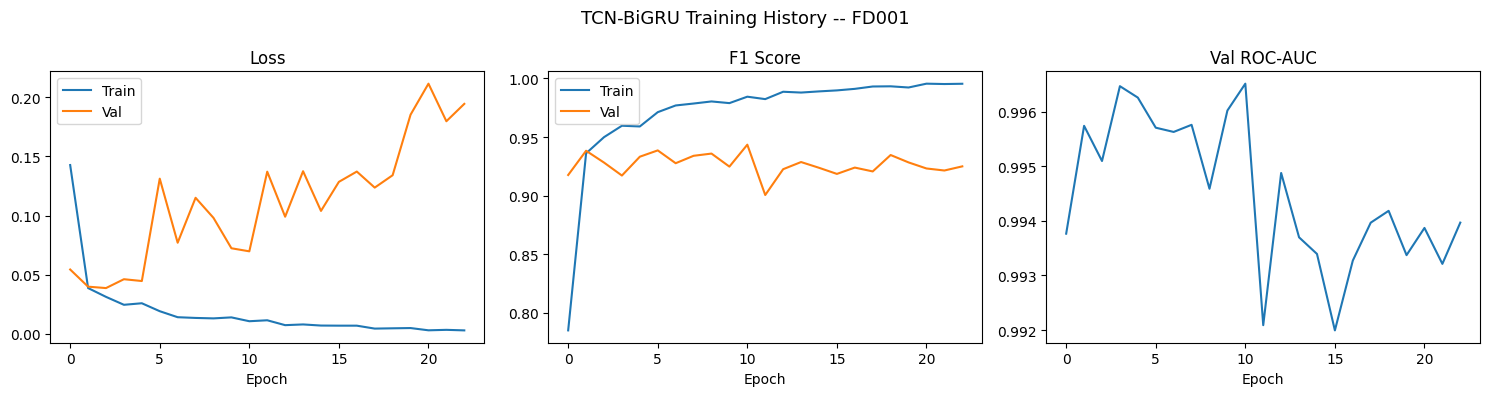

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history['tr_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend()

axes[1].plot(history['tr_f1'], label='Train')
axes[1].plot(history['val_f1'], label='Val')
axes[1].set_title('F1 Score'); axes[1].set_xlabel('Epoch'); axes[1].legend()

axes[2].plot(history['val_auc'])
axes[2].set_title('Val ROC-AUC'); axes[2].set_xlabel('Epoch')

plt.suptitle(f'TCN-BiGRU Training History -- {FD}', fontsize=13)
plt.tight_layout()
plt.show()

## Embedding Extraction (for XGBoost)

In [12]:
@torch.no_grad()
def extract_embeddings(X_np, batch_size=512):
    """Convert raw window array to embedding array via the trained TCN-BiGRU."""
    model.eval()
    embs = []
    for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X_np)),
                             batch_size=batch_size, shuffle=False):
        embs.append(model.embed(xb.to(DEVICE)).detach().cpu().numpy())
    return np.vstack(embs)


print('Extracting embeddings...')
emb_tr  = extract_embeddings(X_tr)
emb_val = extract_embeddings(X_val)
emb_te  = extract_embeddings(X_te)
print(f'emb_tr: {emb_tr.shape}  emb_val: {emb_val.shape}  emb_te: {emb_te.shape}')

# Merge train + val for final XGBoost training
emb_tr_full = np.vstack([emb_tr, emb_val])
y_tr_full   = np.concatenate([y_tr, y_val])

Extracting embeddings...
emb_tr: (14254, 128)  emb_val: (2477, 128)  emb_te: (100, 128)


## XGBoost Hyperparameter Search (GridSearchCV)

Grid search over key XGBoost parameters using stratified k-fold CV scored on F1.

In [13]:
scale_pos    = float((y_tr_full == 0).sum() / (y_tr_full == 1).sum())
scale_pos_bst = scale_pos * CFG['pos_weight_boost']   # boosted weight for XGBoost
BETA          = CFG['recall_beta']

# F-beta scorer: beta>1 weights recall more than precision
f_beta_scorer = make_scorer(fbeta_score, beta=BETA, zero_division=0)

# Parameter grid
param_grid = {
    'max_depth'        : [4, 6, 8],
    'learning_rate'    : [0.01, 0.05, 0.1],
    'min_child_weight' : [1, 3, 5],
    'subsample'        : [0.7, 0.8, 1.0],
    'colsample_bytree' : [0.7, 0.8, 1.0],
    'reg_alpha'        : [0.0, 0.1, 0.5],
    'reg_lambda'       : [0.5, 1.0, 2.0],
}

xgb_base = XGBClassifier(
    objective        = 'binary:logistic',
    n_estimators     = 300,
    scale_pos_weight = scale_pos_bst,   # boosted
    tree_method      = 'hist',
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0,
)

cv_strategy = StratifiedKFold(
    n_splits=CFG['grid_cv_folds'], shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    scoring    = f_beta_scorer,   # optimise F-beta (recall-weighted)
    cv         = cv_strategy,
    n_jobs     = CFG['grid_n_jobs'],
    verbose    = 2,
    refit      = True,
)

print(f'Running GridSearchCV ({CFG["grid_cv_folds"]}-fold CV, scoring=F{BETA:.0f}, scale_pos_weight={scale_pos_bst:.2f})...')
grid_search.fit(emb_tr_full, y_tr_full)

best_params = grid_search.best_params_
best_cv_fb  = grid_search.best_score_

print(f'\n' + '=' * 58)
print(f'  Best CV F{BETA:.0f}  : {best_cv_fb:.4f}')
print(f'  Best parameters:')
for k, v in best_params.items():
    print(f'    {k:<22}: {v}')
print('=' * 58)

# Top-10 configurations
cv_df = pd.DataFrame(grid_search.cv_results_)
top10 = (
    cv_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']]
    .sort_values('rank_test_score').head(10).reset_index(drop=True)
)
top10.index += 1
top10.columns = [f'Parameters', f'Mean F{BETA:.0f}', f'Std F{BETA:.0f}', 'Rank']
top10.iloc[:, 1] = top10.iloc[:, 1].round(4)
top10.iloc[:, 2] = top10.iloc[:, 2].round(4)
print(f'\nTop-10 configurations:')
print(top10.to_string())

Running GridSearchCV (3-fold CV, scoring=F2, scale_pos_weight=9.15)...
Fitting 3 folds for each of 2187 candidates, totalling 6561 fits

  Best CV F2  : 0.9843
  Best parameters:
    colsample_bytree      : 0.8
    learning_rate         : 0.01
    max_depth             : 6
    min_child_weight      : 5
    reg_alpha             : 0.5
    reg_lambda            : 2.0
    subsample             : 0.7

Top-10 configurations:
                                                                                                                                        Parameters  Mean F2  Std F2  Rank
1   {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 6, 'min_child_weight': 5, 'reg_alpha': 0.5, 'reg_lambda': 2.0, 'subsample': 0.7}   0.9843  0.0018     1
2   {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 4, 'min_child_weight': 5, 'reg_alpha': 0.5, 'reg_lambda': 0.5, 'subsample': 0.7}   0.9843  0.0018     2
3   {'colsample_bytree': 0.7, 'learning_rate': 0.01, 'max_depth': 

## XGBoost Final Training (Best Hyperparameters)

In [14]:
dtrain = xgb.DMatrix(emb_tr_full, label=y_tr_full)
dval   = xgb.DMatrix(emb_val,     label=y_val)
dtest  = xgb.DMatrix(emb_te,      label=y_te)

xgb_params = {
    'objective'        : 'binary:logistic',
    'eval_metric'      : ['logloss', 'auc'],
    'eta'              : best_params.get('learning_rate',    CFG['xgb_lr']),
    'max_depth'        : best_params.get('max_depth',        CFG['xgb_depth']),
    'subsample'        : best_params.get('subsample',        CFG['xgb_subsample']),
    'colsample_bytree' : best_params.get('colsample_bytree', CFG['xgb_colsample']),
    'min_child_weight' : best_params.get('min_child_weight', CFG['xgb_min_child']),
    'reg_alpha'        : best_params.get('reg_alpha',        CFG['xgb_alpha']),
    'reg_lambda'       : best_params.get('reg_lambda',       CFG['xgb_lambda']),
    'scale_pos_weight' : scale_pos_bst,   # boosted to favour recall
    'tree_method'      : 'hist',
    'seed'             : 42,
}

evals_result = {}
xgb_model = xgb.train(
    xgb_params,
    dtrain,
    num_boost_round       = CFG['xgb_rounds'],
    evals                 = [(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds = CFG['xgb_es_rounds'],
    evals_result          = evals_result,
    verbose_eval          = 50,
)
print(f'\nBest boosting round: {xgb_model.best_iteration}')

[0]	train-logloss:0.94505	train-auc:0.99805	val-logloss:0.94390	val-auc:0.99073
[50]	train-logloss:0.46370	train-auc:0.99940	val-logloss:0.47479	val-auc:0.99684
[100]	train-logloss:0.26108	train-auc:0.99958	val-logloss:0.27822	val-auc:0.99753
[150]	train-logloss:0.15671	train-auc:0.99968	val-logloss:0.17677	val-auc:0.99805
[200]	train-logloss:0.09845	train-auc:0.99979	val-logloss:0.12053	val-auc:0.99854
[250]	train-logloss:0.06452	train-auc:0.99990	val-logloss:0.08766	val-auc:0.99902
[300]	train-logloss:0.04444	train-auc:0.99991	val-logloss:0.06818	val-auc:0.99908
[350]	train-logloss:0.03240	train-auc:0.99991	val-logloss:0.05654	val-auc:0.99913
[400]	train-logloss:0.02502	train-auc:0.99992	val-logloss:0.04915	val-auc:0.99916
[450]	train-logloss:0.02041	train-auc:0.99992	val-logloss:0.04437	val-auc:0.99921
[500]	train-logloss:0.01745	train-auc:0.99993	val-logloss:0.04093	val-auc:0.99926
[550]	train-logloss:0.01554	train-auc:0.99993	val-logloss:0.03841	val-auc:0.99931
[600]	train-logloss

## Threshold Optimisation (Max F1 on Validation Set)

In [15]:
val_probs = xgb_model.predict(dval)
BETA      = CFG['recall_beta']
MIN_PREC  = CFG['min_precision']

best_thr, best_fb = 0.5, 0.0
for thr in np.arange(0.05, 0.95, 0.01):
    preds_thr = (val_probs > thr).astype(int)
    if preds_thr.sum() == 0:
        continue
    prec_thr = float((preds_thr & y_val).sum()) / (preds_thr.sum() + 1e-9)
    if prec_thr < MIN_PREC:      # skip thresholds with unacceptably low precision
        continue
    fb = fbeta_score(y_val, preds_thr, beta=BETA, zero_division=0)
    if fb > best_fb:
        best_fb, best_thr = fb, thr

rec_at_thr  = recall_score(y_val, (val_probs > best_thr).astype(int), zero_division=0)
prec_at_thr = float(((val_probs > best_thr).astype(int) & y_val).sum()) /               ((val_probs > best_thr).sum() + 1e-9)

print(f'Optimal threshold (F{BETA:.0f}, min_prec>={MIN_PREC}): {best_thr:.2f}')
print(f'  Val F{BETA:.0f}       : {best_fb:.4f}')
print(f'  Val Recall    : {rec_at_thr:.4f}')
print(f'  Val Precision : {prec_at_thr:.4f}')

Optimal threshold (F2, min_prec>=0.35): 0.70
  Val F2       : 0.9938
  Val Recall    : 1.0000
  Val Precision : 0.9698


## Test Set Evaluation

In [16]:
test_probs = xgb_model.predict(dtest)
test_preds = (test_probs > best_thr).astype(int)

f1  = f1_score(y_te, test_preds, zero_division=0)
auc = roc_auc_score(y_te, test_probs)
ap  = average_precision_score(y_te, test_probs)

cm            = confusion_matrix(y_te, test_preds)
tn, fp, fn, tp_count = cm.ravel()
precision     = tp_count / (tp_count + fp + 1e-9)
recall        = tp_count / (tp_count + fn + 1e-9)
spec          = tn / (tn + fp + 1e-9)

print('=' * 55)
print(f'  Dataset              : {FD}')
print(f'  Threshold            : {best_thr:.2f}')
print(f'  Test F1 Score        : {f1:.4f}')
print(f'  Test ROC-AUC         : {auc:.4f}')
print(f'  Test Avg Precision   : {ap:.4f}')
print(f'  Precision            : {precision:.4f}')
print(f'  Recall (Sensitivity) : {recall:.4f}')
print(f'  Specificity          : {spec:.4f}')
print('=' * 55)
print()
print(classification_report(y_te, test_preds,
                             target_names=['Normal', 'Near Failure']))

  Dataset              : FD001
  Threshold            : 0.70
  Test F1 Score        : 0.8636
  Test ROC-AUC         : 0.9973
  Test Avg Precision   : 0.9916
  Precision            : 1.0000
  Recall (Sensitivity) : 0.7600
  Specificity          : 1.0000

              precision    recall  f1-score   support

      Normal       0.93      1.00      0.96        75
Near Failure       1.00      0.76      0.86        25

    accuracy                           0.94       100
   macro avg       0.96      0.88      0.91       100
weighted avg       0.94      0.94      0.94       100



## Results Dashboard

Six-panel dashboard: confusion matrix, ROC curve, PR curve, score distribution, XGBoost feature importance, and metrics bar chart.

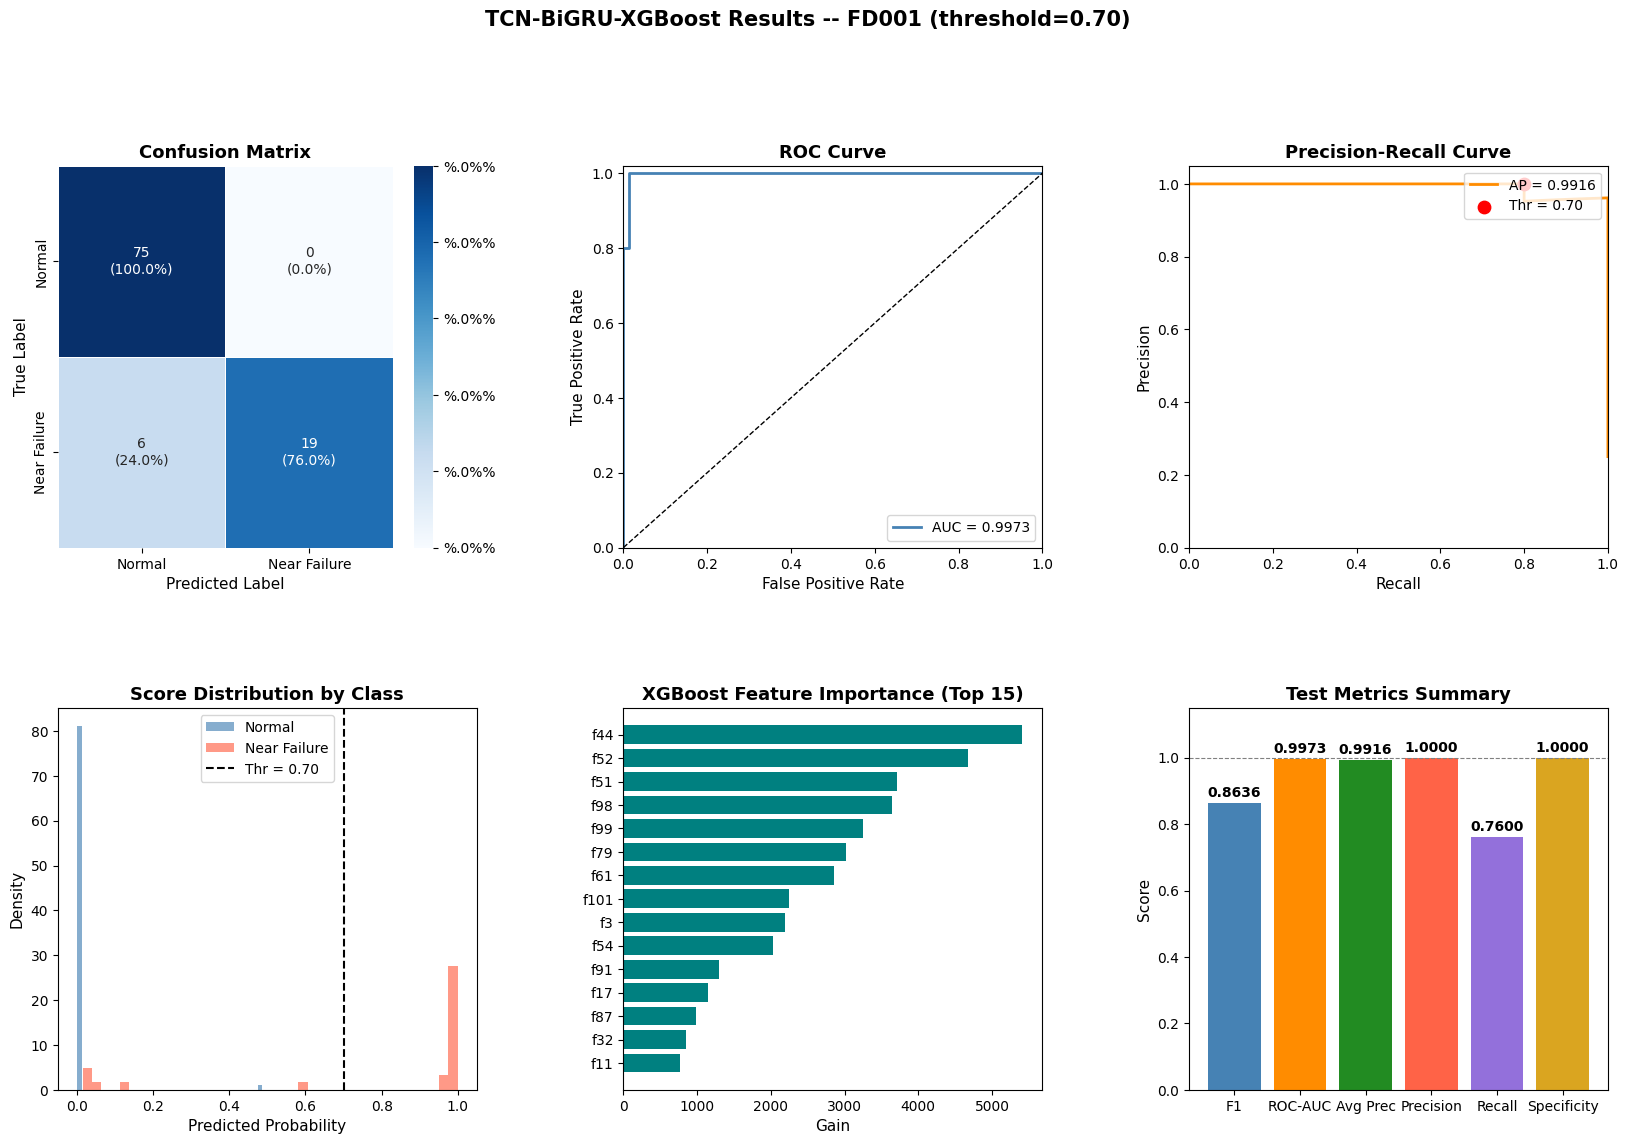

Dashboard saved: results_dashboard_FD001.png


In [17]:
def plot_confusion(ax, y_true, y_pred, classes=('Normal', 'Near Failure')):
    cm_raw  = confusion_matrix(y_true, y_pred)
    cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)
    annot   = [[f'{v}\n({p:.1%})' for v, p in zip(rv, rp)]
                for rv, rp in zip(cm_raw, cm_norm)]
    sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Blues', ax=ax,
                xticklabels=classes, yticklabels=classes,
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={'format': '%.0%%'})
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')


def plot_roc(ax, y_true, y_score):
    fpr, tpr, _ = roc_curve(y_true, y_score)
    auc_v = roc_auc_score(y_true, y_score)
    ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'AUC = {auc_v:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title('ROC Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='lower right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])


def plot_pr(ax, y_true, y_score, threshold):
    prec, rec, thrs = precision_recall_curve(y_true, y_score)
    ap_v = average_precision_score(y_true, y_score)
    ax.plot(rec, prec, lw=2, color='darkorange', label=f'AP = {ap_v:.4f}')
    if len(thrs) > 0:
        idx = np.argmin(np.abs(thrs - threshold))
        ax.scatter(rec[idx], prec[idx], color='red', zorder=5, s=80,
                   label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right')
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])


def plot_score_dist(ax, y_true, y_score, threshold):
    for label, color, name in [(0, 'steelblue', 'Normal'),
                                (1, 'tomato', 'Near Failure')]:
        ax.hist(y_score[y_true == label], bins=40, alpha=0.65,
                color=color, label=name, density=True)
    ax.axvline(threshold, color='black', linestyle='--', lw=1.5,
               label=f'Thr = {threshold:.2f}')
    ax.set_xlabel('Predicted Probability', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title('Score Distribution by Class', fontsize=13, fontweight='bold')
    ax.legend()


def plot_feat_importance(ax, model, top_n=15):
    scores = model.get_score(importance_type='gain')
    if not scores:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); return
    s_sorted = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:top_n]
    feats, vals = zip(*s_sorted)
    ax.barh(feats[::-1], vals[::-1], color='teal')
    ax.set_xlabel('Gain', fontsize=11)
    ax.set_title(f'XGBoost Feature Importance (Top {top_n})',
                 fontsize=13, fontweight='bold')


def plot_metrics_bar(ax, metrics_dict):
    names  = list(metrics_dict.keys())
    values = list(metrics_dict.values())
    colors = ['steelblue', 'darkorange', 'forestgreen',
              'tomato', 'mediumpurple', 'goldenrod']
    bars   = ax.bar(names, values, color=colors[:len(names)])
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Test Metrics Summary', fontsize=13, fontweight='bold')
    ax.axhline(1.0, color='gray', linestyle='--', lw=0.8)


metrics_dict = {
    'F1'         : f1,
    'ROC-AUC'    : auc,
    'Avg Prec'   : ap,
    'Precision'  : precision,
    'Recall'     : recall,
    'Specificity': spec,
}

fig = plt.figure(figsize=(20, 12))
fig.suptitle(f'TCN-BiGRU-XGBoost Results -- {FD} (threshold={best_thr:.2f})',
             fontsize=15, fontweight='bold', y=1.01)
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[0, 2])
ax4 = fig.add_subplot(gs[1, 0])
ax5 = fig.add_subplot(gs[1, 1])
ax6 = fig.add_subplot(gs[1, 2])

plot_confusion(ax1, y_te, test_preds)
plot_roc(ax2, y_te, test_probs)
plot_pr(ax3, y_te, test_probs, best_thr)
plot_score_dist(ax4, y_te, test_probs, best_thr)
plot_feat_importance(ax5, xgb_model)
plot_metrics_bar(ax6, metrics_dict)

plt.savefig(f'results_dashboard_{FD}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Dashboard saved: results_dashboard_{FD}.png')

## Metrics Summary Table

In [18]:
report_dict = classification_report(
    y_te, test_preds, target_names=['Normal', 'Near Failure'], output_dict=True)

rows = []
for cls in ['Normal', 'Near Failure']:
    rows.append({
        'Class'    : cls,
        'Precision': round(report_dict[cls]['precision'], 4),
        'Recall'   : round(report_dict[cls]['recall'],    4),
        'F1-Score' : round(report_dict[cls]['f1-score'],  4),
        'Support'  : int(report_dict[cls]['support']),
    })
for name, val in [('Overall F1', f1), ('ROC-AUC', auc),
                  ('Avg Precision', ap), ('Specificity', spec)]:
    rows.append({'Class': name, 'Precision': round(val, 4),
                 'Recall': '--', 'F1-Score': '--', 'Support': '--'})

df_summary = pd.DataFrame(rows).set_index('Class')

print('\n' + '=' * 60)
print(f'  {FD} -- TCN-BiGRU + XGBoost (GridSearchCV)')
print('=' * 60)
print(df_summary.to_string())
print('=' * 60)

try:
    from IPython.display import display
    styled = (
        df_summary.style
        .set_caption(f'TCN-BiGRU-XGBoost Results -- {FD}')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 12px')]},
        ])
    )
    display(styled)
except Exception:
    pass


  FD001 -- TCN-BiGRU + XGBoost (GridSearchCV)
               Precision Recall F1-Score Support
Class                                           
Normal            0.9259    1.0   0.9615      75
Near Failure      1.0000   0.76   0.8636      25
Overall F1        0.8636     --       --      --
ROC-AUC           0.9973     --       --      --
Avg Precision     0.9916     --       --      --
Specificity       1.0000     --       --      --


,Precision,Recall,F1-Score,Support
Class,,,,
Normal,0.925900,1.000000,0.961500,75
Near Failure,1.000000,0.760000,0.863600,25
Overall F1,0.863600,--,--,--
ROC-AUC,0.997300,--,--,--
Avg Precision,0.991600,--,--,--
Specificity,1.000000,--,--,--


## Full FD001-FD004 Batch Evaluation

In [19]:
def run_full_pipeline(fd, cfg=CFG):
    """Run the complete TCN-BiGRU + XGBoost (GridSearchCV, recall-boosted) pipeline."""
    seed_everything(42)
    train_r, test_r, rul_r = load_raw(fd)
    train_r = add_rul(train_r)
    tr, va  = split_train_val(train_r, cfg['val_engine_frac'])
    fc      = get_features(tr)

    sc = StandardScaler()
    tr[fc]     = sc.fit_transform(tr[fc])
    va[fc]     = sc.transform(va[fc])
    test_r[fc] = sc.transform(test_r[fc])

    SL, ST, TH = cfg['seq_len'], cfg['stride'], cfg['rul_threshold']
    Xtr, ytr = make_sliding_windows(tr, fc, SL, ST, TH)
    Xva, yva = make_sliding_windows(va, fc, SL, ST, TH)
    Xte, yte = make_test_windows(test_r, rul_r, fc, SL, TH)

    # Train TCN-BiGRU with boosted pos_weight
    m    = TCNBiGRU(Xtr.shape[2], cfg).to(DEVICE)
    raw_pr = float((ytr == 0).sum() / (ytr == 1).sum())
    pw   = torch.tensor([raw_pr * cfg['pos_weight_boost']],
                        dtype=torch.float32).to(DEVICE)
    crit = FocalLoss(gamma=cfg['focal_gamma'], pos_weight=pw)
    opt  = torch.optim.AdamW(m.parameters(), lr=cfg['lr'],
                              weight_decay=cfg['weight_decay'])
    sch  = torch.optim.lr_scheduler.CosineAnnealingLR(
        opt, T_max=cfg['epochs'], eta_min=1e-5)
    trl  = get_loader(Xtr, ytr, cfg['batch_size'])
    vll  = get_loader(Xva, yva, cfg['batch_size'], shuffle=False)
    BETA = cfg['recall_beta']

    best_fb, best_st, no_imp = -1, None, 0
    for ep in range(1, cfg['epochs'] + 1):
        m.train()
        for xb, yb in trl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            loss = crit(m(xb), yb)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
        sch.step()
        m.eval(); vp, vt = [], []
        with torch.no_grad():
            for xb, yb in vll:
                vp.extend(torch.sigmoid(m(xb.to(DEVICE))).cpu().numpy())
                vt.extend(yb.numpy())
        vfb = fbeta_score(vt, (np.array(vp) > 0.5).astype(int),
                          beta=BETA, zero_division=0)
        if vfb > best_fb:
            best_fb = vfb
            best_st = {k: v.cpu().clone() for k, v in m.state_dict().items()}
            no_imp  = 0
        else:
            no_imp += 1
        if no_imp >= cfg['patience']:
            break
    m.load_state_dict(best_st)

    @torch.no_grad()
    def _emb(X):
        m.eval(); parts = []
        for (xb,) in DataLoader(TensorDataset(torch.from_numpy(X)), batch_size=512):
            parts.append(m.embed(xb.to(DEVICE)).cpu().numpy())
        return np.vstack(parts)

    etr_f = np.vstack([_emb(Xtr), _emb(Xva)])
    ytr_f = np.concatenate([ytr, yva])
    eva, ete = _emb(Xva), _emb(Xte)

    # GridSearchCV with F-beta scorer + boosted scale_pos_weight
    sp     = float((ytr_f == 0).sum() / (ytr_f == 1).sum())
    sp_bst = sp * cfg['pos_weight_boost']
    f_beta = make_scorer(fbeta_score, beta=BETA, zero_division=0)

    gs = GridSearchCV(
        XGBClassifier(objective='binary:logistic', n_estimators=300,
                      scale_pos_weight=sp_bst, tree_method='hist',
                      eval_metric='logloss', random_state=42, verbosity=0),
        param_grid={
            'max_depth'        : [4, 6],
            'learning_rate'    : [0.03, 0.1],
            'min_child_weight' : [1, 3],
            'subsample'        : [0.8, 1.0],
            'colsample_bytree' : [0.8, 1.0],
        },
        scoring=f_beta,
        cv=StratifiedKFold(3, shuffle=True, random_state=42),
        n_jobs=-1, verbose=0,
    )
    gs.fit(etr_f, ytr_f)
    bp = gs.best_params_

    xm = xgb.train(
        {'objective': 'binary:logistic', 'eval_metric': ['logloss', 'auc'],
         'eta': bp.get('learning_rate', cfg['xgb_lr']),
         'max_depth': bp.get('max_depth', cfg['xgb_depth']),
         'subsample': bp.get('subsample', cfg['xgb_subsample']),
         'colsample_bytree': bp.get('colsample_bytree', cfg['xgb_colsample']),
         'min_child_weight': bp.get('min_child_weight', cfg['xgb_min_child']),
         'reg_alpha': cfg['xgb_alpha'], 'reg_lambda': cfg['xgb_lambda'],
         'scale_pos_weight': sp_bst, 'tree_method': 'hist', 'seed': 42},
        xgb.DMatrix(etr_f, label=ytr_f),
        num_boost_round=cfg['xgb_rounds'],
        evals=[(xgb.DMatrix(eva, label=yva), 'val')],
        early_stopping_rounds=cfg['xgb_es_rounds'],
        verbose_eval=False,
    )

    # F-beta + min_precision threshold optimisation
    vp2    = xm.predict(xgb.DMatrix(eva))
    MIN_PR = cfg['min_precision']
    thr2, fb2 = 0.5, 0.0
    for t in np.arange(0.05, 0.95, 0.01):
        pt = (vp2 > t).astype(int)
        if pt.sum() == 0: continue
        pr_t = float((pt & yva).sum()) / (pt.sum() + 1e-9)
        if pr_t < MIN_PR: continue
        fv = fbeta_score(yva, pt, beta=BETA, zero_division=0)
        if fv > fb2:
            fb2, thr2 = fv, t

    tp  = xm.predict(xgb.DMatrix(ete))
    pr  = (tp > thr2).astype(int)
    cm2 = confusion_matrix(yte, pr)
    tn2, fp2, fn2, tp2 = cm2.ravel()
    return {
        'F1'         : f1_score(yte, pr, zero_division=0),
        'AUC'        : roc_auc_score(yte, tp) if len(np.unique(yte)) > 1 else float('nan'),
        'Avg Prec'   : average_precision_score(yte, tp),
        'Precision'  : tp2 / (tp2 + fp2 + 1e-9),
        'Recall'     : tp2 / (tp2 + fn2 + 1e-9),
        'Specificity': tn2 / (tn2 + fp2 + 1e-9),
        'Best Params': str(bp),
    }


print('Running all CMAPSS datasets...')
all_results = {}
for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f'\n--- {fd} ---', flush=True)
    r = run_full_pipeline(fd)
    all_results[fd] = r
    print(f"  F1={r['F1']:.4f}  Recall={r['Recall']:.4f}  "
          f"Precision={r['Precision']:.4f}  AUC={r['AUC']:.4f}")

Running all CMAPSS datasets...

--- FD001 ---
  F1=0.8889  Recall=0.8000  Precision=1.0000  AUC=0.9968

--- FD002 ---
  F1=0.9302  Recall=1.0000  Precision=0.8696  AUC=0.9980

--- FD003 ---
  F1=0.9231  Recall=0.9000  Precision=0.9474  AUC=0.9988

--- FD004 ---
  F1=0.8932  Recall=0.8846  Precision=0.9020  AUC=0.9826


## Cross-Dataset Results Table

  TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Results
           F1     AUC  Avg Prec  Precision  Recall  Specificity
FD001  0.8889  0.9968    0.9902     1.0000  0.8000       1.0000
FD002  0.9302  0.9980    0.9938     0.8696  1.0000       0.9548
FD003  0.9231  0.9988    0.9951     0.9474  0.9000       0.9875
FD004  0.8932  0.9826    0.9469     0.9020  0.8846       0.9745
Mean   0.9089  0.9940    0.9815     0.9297  0.8962       0.9792
Std    0.0208  0.0076    0.0232     0.0567  0.0820       0.0193


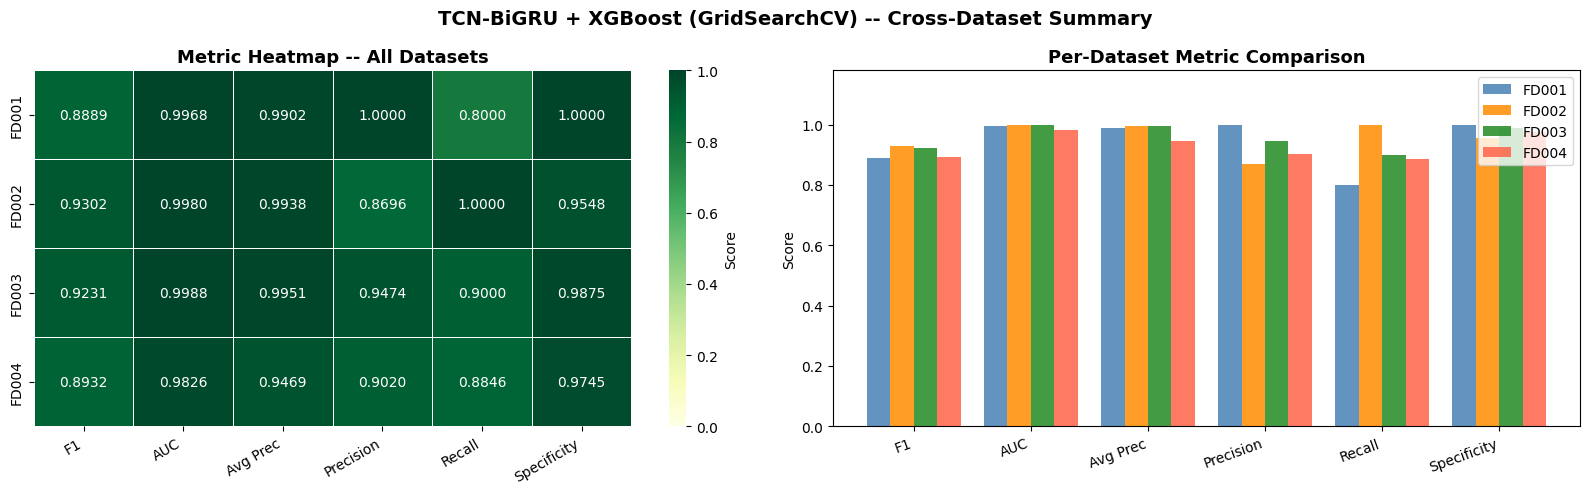

Saved: cross_dataset_results.png


,F1,AUC,Avg Prec,Precision,Recall,Specificity
FD001,0.888900,0.996800,0.990200,1.000000,0.800000,1.000000
FD002,0.930200,0.998000,0.993800,0.869600,1.000000,0.954800
FD003,0.923100,0.998800,0.995100,0.947400,0.900000,0.987500
FD004,0.893200,0.982600,0.946900,0.902000,0.884600,0.974500
Mean,0.908900,0.994000,0.981500,0.929700,0.896200,0.979200
Std,0.020800,0.007600,0.023200,0.056700,0.082000,0.019300


In [20]:
metric_cols = ['F1', 'AUC', 'Avg Prec', 'Precision', 'Recall', 'Specificity']

df_res = pd.DataFrame(
    {k: {m: v[m] for m in metric_cols} for k, v in all_results.items()}
).T.astype(float)
df_res.loc['Mean'] = df_res.mean()
df_res.loc['Std']  = df_res.iloc[:-1].std()

print('=' * 70)
print('  TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Results')
print('=' * 70)
print(df_res.round(4).to_string())
print('=' * 70)

# Heatmap + grouped bar chart
fig, (ax_heat, ax_bar) = plt.subplots(1, 2, figsize=(16, 5))

heat_data = df_res.loc[['FD001', 'FD002', 'FD003', 'FD004']]
sns.heatmap(heat_data.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0, vmax=1, ax=ax_heat, linewidths=0.5,
            cbar_kws={'label': 'Score'})
ax_heat.set_title('Metric Heatmap -- All Datasets', fontsize=13, fontweight='bold')
ax_heat.set_xticklabels(metric_cols, rotation=30, ha='right')

x      = np.arange(len(metric_cols))
w      = 0.2
fds    = ['FD001', 'FD002', 'FD003', 'FD004']
colors = ['steelblue', 'darkorange', 'forestgreen', 'tomato']
for i, (fd_name, col) in enumerate(zip(fds, colors)):
    vals = df_res.loc[fd_name, metric_cols].values.astype(float)
    ax_bar.bar(x + i * w, vals, width=w, label=fd_name, color=col, alpha=0.85)
ax_bar.set_xticks(x + 1.5 * w)
ax_bar.set_xticklabels(metric_cols, rotation=20, ha='right')
ax_bar.set_ylim(0, 1.18)
ax_bar.set_ylabel('Score')
ax_bar.set_title('Per-Dataset Metric Comparison', fontsize=13, fontweight='bold')
ax_bar.legend()

plt.suptitle('TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Summary',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cross_dataset_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: cross_dataset_results.png')

# Styled Jupyter table
try:
    from IPython.display import display
    styled = (
        df_res.round(4).style
        .background_gradient(cmap='YlGn', subset=metric_cols, vmin=0, vmax=1)
        .set_caption('TCN-BiGRU + XGBoost (GridSearchCV) -- Cross-Dataset Results')
        .set_table_styles([
            {'selector': 'caption',
             'props': [('font-size', '14px'), ('font-weight', 'bold'), ('padding', '8px')]},
            {'selector': 'th',
             'props': [('background-color', '#4472C4'), ('color', 'white'),
                       ('font-weight', 'bold'), ('text-align', 'center')]},
            {'selector': 'td',
             'props': [('text-align', 'center'), ('padding', '6px 14px')]},
        ])
        .highlight_max(subset=metric_cols, axis=0,
                       props='font-weight: bold; border: 2px solid #2F75B6;')
    )
    display(styled)
except Exception:
    pass

## Model Saving

In [21]:
SAVE_DIR = '/content/drive/MyDrive/models'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f'{SAVE_DIR}/tcn_bigru_{FD}.pt')
xgb_model.save_model(f'{SAVE_DIR}/xgb_{FD}.ubj')

print(f'Models saved to {SAVE_DIR}/')
print(f'  tcn_bigru_{FD}.pt')
print(f'  xgb_{FD}.ubj')

Models saved to /content/drive/MyDrive/models/
  tcn_bigru_FD001.pt
  xgb_FD001.ubj
